# 04 — Evaluation and Error Analysis

## Metrics
All metrics are reported in **basis points** on the held-out test set
(last 20% of bars — never touched during training or validation).

| Metric | Description |
|--------|-------------|
| MAE    | Mean absolute error — primary metric, directly interpretable |
| RMSE   | Root mean squared error — emphasises large errors |
| MedAE  | Median absolute error — robust to outliers |

## Baselines
1. **Mean predictor** — always predicts training-set mean slippage
2. **Linear (Ridge)** — same features, linear model
3. **Heuristic** — β × order_size_fraction × vol_rolling, β calibrated on val

## Error analysis segments
Order size (Q1–Q4) · Volatility (Q1–Q4) · Time of day (open/mid/close) · Buy vs sell · Volume regime

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

from slippage.features import FEATURE_NAMES_TRAINING
from slippage.pipeline import build_full_dataset
from slippage.models import SlippageMLP
from slippage.training import predict
from slippage.models import MeanPredictor, LinearBaseline, HeuristicBaseline
from slippage.evaluation import global_metrics, segment_breakdown, evaluate_all
from slippage.paths import CHECKPOINTS_DIR, RESULTS_DIR
from slippage.viz import (
    plot_pred_vs_actual,
    plot_error_by_segment,
    plot_feature_importance,
    FIGURES_DIR,
)

In [2]:
# Rebuild data and split via the shared pipeline. split.test_df is
# guaranteed to align row-by-row with split.y_test / X_test.
data, proxy_all, split = build_full_dataset()
n_tr, n_v, n_te = len(split.X_train), len(split.X_val), len(split.X_test)
print(f'Train: {n_tr:,}  Val: {n_v:,}  Test: {n_te:,}')

test_df = split.test_df  # no more iloc tricks

[data] SPY: 3425 bars (2024-06-05 → 2026-05-22)
[data] QQQ: 3407 bars (2024-06-05 → 2026-05-22)
[data] IWM: 3427 bars (2024-06-05 → 2026-05-22)
[data] AAPL: 3419 bars (2024-06-05 → 2026-05-22)
[data] MSFT: 3419 bars (2024-06-05 → 2026-05-22)
[data] GOOGL: 3424 bars (2024-06-05 → 2026-05-22)
[data] JPM: 3427 bars (2024-06-05 → 2026-05-22)
[data] GS: 3427 bars (2024-06-05 → 2026-05-22)
[data] XOM: 3426 bars (2024-06-05 → 2026-05-22)
[data] SLB: 3427 bars (2024-06-05 → 2026-05-22)
[data] PRCT: 3427 bars (2024-06-05 → 2026-05-22)


Train: 97,331  Val: 22,461  Test: 29,948


In [3]:
# Load trained model from the canonical artifacts/checkpoints/ location.
checkpoint = torch.load(CHECKPOINTS_DIR / 'model_checkpoint.pt', weights_only=True)
model = SlippageMLP(n_features=checkpoint['n_features'])
model.load_state_dict(checkpoint['state_dict'])
y_pred_mlp = predict(model, split.X_test)
y_test = split.y_test

In [4]:
# Fit baselines
mean_pred = MeanPredictor().fit(split.X_train, split.y_train)
linear_pred = LinearBaseline().fit(split.X_train, split.y_train)
heuristic = HeuristicBaseline(FEATURE_NAMES_TRAINING)
heuristic.fit(split.X_val, split.y_val, split.scaler.mean_, split.scaler.scale_)

y_pred_mean = mean_pred.predict(split.X_test)
y_pred_linear = linear_pred.predict(split.X_test)
y_pred_heuristic = heuristic.predict(split.X_test, split.scaler.mean_, split.scaler.scale_)

In [5]:
# Full evaluation: saves metrics.json (global + segment_breakdown + per_ticker) and prints summary
results = evaluate_all(
    split,
    model_predict_fn=lambda X: predict(model, X),
    baselines={
        'linear':    lambda X: linear_pred.predict(X),
        'heuristic': lambda X: heuristic.predict(X, split.scaler.mean_, split.scaler.scale_),
        'mean':      lambda X: mean_pred.predict(X),
    },
)
print(f'Full metrics (incl. segment_breakdown + per_ticker) saved to {RESULTS_DIR}/metrics.json\n')

# Filter to top-level model-metric entries only — skip the nested per_ticker / segment_breakdown
# entries that would otherwise explode into ticker-name columns.
metrics_df = pd.DataFrame({
    k: {kk: vv for kk, vv in v.items() if kk != 'segment_breakdown'}
    for k, v in results.items()
    if isinstance(v, dict) and 'mae_bps' in v
}).T
print('=== Global Metrics (test set, bps) ===')
print(metrics_df.round(3).to_string())

Full metrics (incl. segment_breakdown + per_ticker) saved to /Users/francesconatale/Documents/projects/slippage-predictor/results/metrics.json

=== Global Metrics (test set, bps) ===
           mae_bps  rmse_bps  med_ae_bps
mlp          5.340    10.126       3.165
linear       7.992    14.803       5.377
heuristic   12.121    21.148       7.297
mean        17.723    31.637      12.733


In [6]:
# Per-ticker MAE breakdown — sorted by MLP MAE ascending
per_ticker = results.get('per_ticker', {})
if per_ticker:
    pt_df = pd.DataFrame(per_ticker).T
    pt_df = pt_df.sort_values('mlp_mae_bps')[
        ['n_samples', 'mlp_mae_bps', 'heuristic_mae_bps',
         'mlp_rmse_bps', 'heuristic_rmse_bps']
    ]
    print('=== Per-ticker MAE (sorted by MLP MAE) ===')
    print(pt_df.round(3).to_string())

=== Per-ticker MAE (sorted by MLP MAE) ===
       n_samples  mlp_mae_bps  heuristic_mae_bps  mlp_rmse_bps  heuristic_rmse_bps
SPY       2732.0        2.516              5.711         3.844               8.443
QQQ       2680.0        3.331              7.421         4.770              10.539
IWM       2732.0        3.828              8.822         5.679              12.988
AAPL      2710.0        4.291              9.768         6.325              14.070
JPM       2736.0        4.409             10.290         6.410              14.526
XOM       2732.0        4.940             11.278         7.360              16.638
GOOGL     2720.0        5.078             11.343         7.700              16.454
MSFT      2706.0        5.377             12.292         9.401              20.399
GS        2732.0        5.962             13.777         8.743              19.738
SLB       2733.0        6.194             14.464         9.134              21.380
PRCT      2735.0       12.760             28

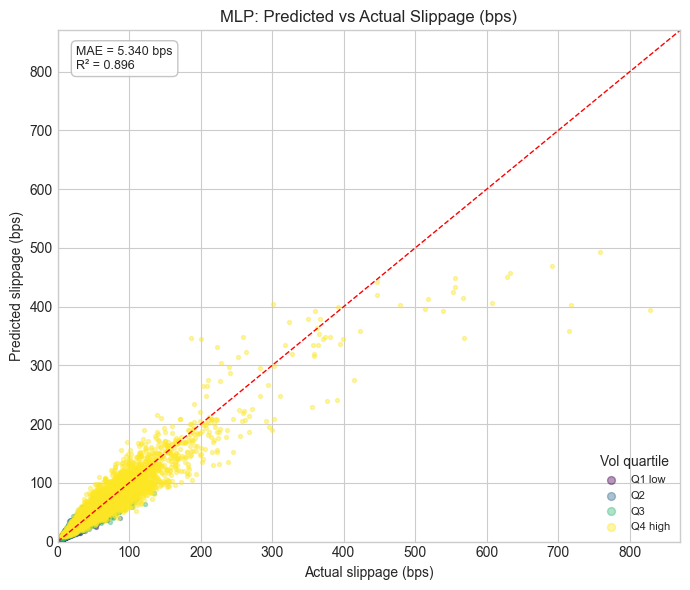

In [7]:
# Predicted vs actual — coloured by vol regime
vol_q = pd.qcut(test_df['vol_rolling'], q=4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
fig = plot_pred_vs_actual(
    y_test, y_pred_mlp,
    regime=vol_q.values,
    regime_label='Vol quartile',
    title='MLP: Predicted vs Actual Slippage (bps)',
    save_as='pred_vs_actual.png',
)
plt.show()

      segment         bucket  n_samples  mae_bps  rmse_bps  med_ae_bps
size_quartile       Q1_small       7487 2.978131  5.106471    1.852836
size_quartile             Q2       7487 4.658901  7.193342    3.098948
size_quartile             Q3       7487 6.150727 11.565689    3.881423
size_quartile       Q4_large       7487 7.572129 14.091760    4.669014
 vol_quartile     Q1_low_vol       7490 2.496045  3.481614    1.783179
 vol_quartile             Q2       7487 3.782371  5.252792    2.757463
 vol_quartile             Q3       7484 5.098251  7.058305    3.729155
 vol_quartile    Q4_high_vol       7487 9.984264 17.906565    6.367799
  time_of_day           open       4268 6.574418 13.690070    3.757864
  time_of_day            mid      21376 4.983685  9.269442    3.009749
  time_of_day          close       4304 5.885365 10.045325    3.560621
         side            buy      14973 5.333860 10.109036    3.152073
         side           sell      14975 5.346083 10.143416    3.182297
volume

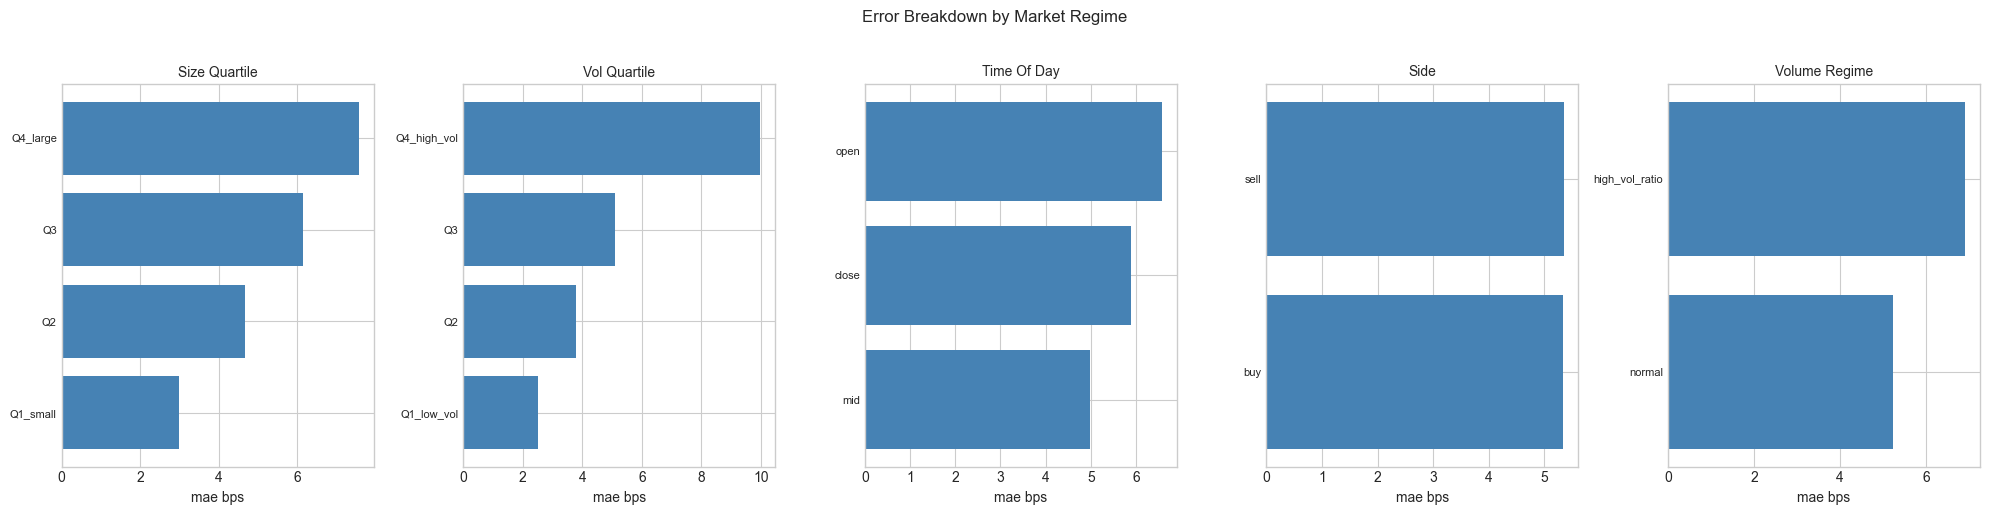

In [8]:
# Error breakdown by segment
breakdown = segment_breakdown(y_test, y_pred_mlp, test_df)
print(breakdown.to_string(index=False))
fig = plot_error_by_segment(breakdown, metric='mae_bps', save_as='error_by_segment.png')
plt.show()

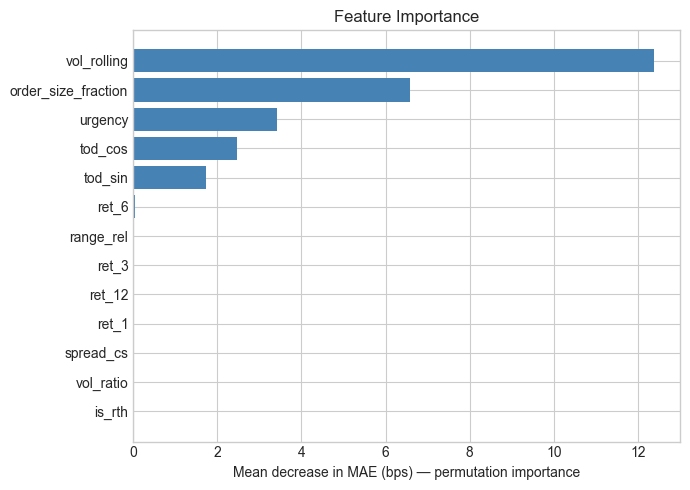

All figures saved to results/figures/


In [9]:
# Feature importance (permutation, on val set)
fig = plot_feature_importance(
    model, split.X_val, split.y_val, FEATURE_NAMES_TRAINING,
    n_repeats=5, seed=42, save_as='feature_importance.png',
)
plt.show()
print('All figures saved to results/figures/')